<a href="https://colab.research.google.com/github/its-emile/read-the-clock/blob/main/AI_clock_reading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Test multiple LLMs on reading time from known analog clocks

In [ ]:
from PIL import Image, ImageDraw
import datetime
import random
import os

def draw_clock(hour, minute, image_size=200, hand_color='black', background_color='white'):
    """
    Draws a clock image for a given hour and minute.
    """
    img = Image.new('RGB', (image_size, image_size), background_color)
    draw = ImageDraw.Draw(img)

    center_x, center_y = image_size // 2, image_size // 2
    radius = image_size // 2 - 10

    # Draw clock face (circle)
    draw.ellipse((center_x - radius, center_y - radius, center_x + radius, center_y + radius), outline=hand_color, width=2)

    # Draw minute marks (every 5 minutes)
    for i in range(0, 60, 5):
        angle_rad = (i / 60) * 2 * 3.141592653589793 - 3.141592653589793 / 2 # Adjust for 12 o'clock at top
        if i % 15 == 0: # Larger marks for 12, 3, 6, 9
            mark_length = radius * 0.1
        else:
            mark_length = radius * 0.05

        x1 = center_x + (radius - mark_length) * math.cos(angle_rad)
        y1 = center_y + (radius - mark_length) * math.sin(angle_rad)
        x2 = center_x + radius * math.cos(angle_rad)
        y2 = center_y + radius * math.sin(angle_rad)
        draw.line((x1, y1, x2, y2), fill=hand_color, width=2)

    # Calculate angles for hands
    # Minute hand: 360 degrees / 60 minutes = 6 degrees per minute
    minute_angle = (minute / 60) * 360 - 90  # -90 to start at 12 o'clock
    # Hour hand: 360 degrees / 12 hours = 30 degrees per hour
    # Also account for minute contribution: (minute / 60) * 30 degrees
    hour_angle = ((hour % 12 + minute / 60) / 12) * 360 - 90 # -90 to start at 12 o'clock

    # Draw minute hand
    min_hand_length = radius * 0.8
    mx = center_x + min_hand_length * math.cos(math.radians(minute_angle))
    my = center_y + min_hand_length * math.sin(math.radians(minute_angle))
    draw.line((center_x, center_y, mx, my), fill=hand_color, width=3)

    # Draw hour hand
    hr_hand_length = radius * 0.6
    hx = center_x + hr_hand_length * math.cos(math.radians(hour_angle))
    hy = center_y + hr_hand_length * math.sin(math.radians(hour_angle))
    draw.line((center_x, center_y, hx, hy), fill=hand_color, width=5)

    # Draw center dot
    draw.ellipse((center_x - 5, center_y - 5, center_x + 5, center_y + 5), fill=hand_color, outline=hand_color)

    return img

# Ensure math module is imported
import math

# Directory to save images
output_dir = "clock_images"
os.makedirs(output_dir, exist_ok=True)

time_mapping = {}

print("Generating clock images...")

# Iterate through 12 hours in 5-minute increments
start_time = datetime.datetime(2000, 1, 1, 0, 0)
end_time = datetime.datetime(2000, 1, 1, 11, 55) # Up to 11:55 for 12 hours coverage

current_time = start_time
while current_time <= end_time:
    hour = current_time.hour
    minute = current_time.minute

    # Generate image
    clock_image = draw_clock(hour, minute)

    # Obfuscated filename
    obfuscated_filename = str(random.randint(10**10, 10**15 - 1)) + ".png"
    file_path = os.path.join(output_dir, obfuscated_filename)

    # Save image
    clock_image.save(file_path)

    # Store mapping
    time_str = current_time.strftime("%H:%M")
    time_mapping[obfuscated_filename] = time_str

    # Increment by 5 minutes
    current_time += datetime.timedelta(minutes=5)

    if (current_time.minute % 30 == 0):
      print(f"Generated images up to {current_time.strftime('%H:%M')}")

print(f"Finished generating {len(time_mapping)} clock images in '{output_dir}/'.")

# Optionally, save the mapping to a file
import json
mapping_file_path = os.path.join(output_dir, "time_mapping.json")
with open(mapping_file_path, 'w') as f:
    json.dump(time_mapping, f, indent=4)

print(f"Time mapping saved to '{mapping_file_path}'.")
print("First 5 entries of the mapping:")
for i, (fname, time) in enumerate(time_mapping.items()):
    if i >= 5:
        break
    print(f"  {fname}: {time}")

Generating clock images...
Generated images up to 00:30
Generated images up to 01:00
Generated images up to 01:30
Generated images up to 02:00
Generated images up to 02:30
Generated images up to 03:00
Generated images up to 03:30
Generated images up to 04:00
Generated images up to 04:30
Generated images up to 05:00
Generated images up to 05:30
Generated images up to 06:00
Generated images up to 06:30
Generated images up to 07:00
Generated images up to 07:30
Generated images up to 08:00
Generated images up to 08:30
Generated images up to 09:00
Generated images up to 09:30
Generated images up to 10:00
Generated images up to 10:30
Generated images up to 11:00
Generated images up to 11:30
Generated images up to 12:00
Finished generating 144 clock images in 'clock_images/'.
Time mapping saved to 'clock_images/time_mapping.json'.
First 5 entries of the mapping:
  610726583507622.png: 00:00
  458077098032249.png: 00:05
  622775423910301.png: 00:10
  279097886847292.png: 00:15
  63579016720217

In [ ]:
import os
import json
from google.colab import userdata
import google.generativeai as genai
from openai import OpenAI

# 4. Load the time_mapping.json
mapping_path = '/content/clock_images/time_mapping.json'
with open(mapping_path, 'r') as f:
    time_mapping = json.load(f)

# 5. Verify files and create full paths list
image_folder = '/content/clock_images/'
evaluation_data = []
missing_files = []

for filename, true_time in time_mapping.items():
    full_path = os.path.join(image_folder, filename)
    if os.path.exists(full_path):
        evaluation_data.append({'path': full_path, 'time': true_time})
    else:
        missing_files.append(filename)

print(f'Successfully loaded {len(evaluation_data)} image paths.')
if missing_files:
    print(f'Warning: {len(missing_files)} files in mapping were not found on disk.')
else:
    print('All mapped files verified.')

Successfully loaded 144 image paths.
All mapped files verified.


In [ ]:
try:
    from google.colab import userdata
    openrouter_api_key = userdata.get("OPENROUTER_API_KEY")
except Exception as e:
    print(f"Warning: Could not retrieve secret from userdata. Error: {e}")
    openrouter_api_key = "YOUR_OPENROUTER_API_KEY" # Fallback for manual entry

# 2. Initialize OpenAI client for OpenRouter
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=openrouter_api_key,
)

# 3. Load mapping and verify files
mapping_path = "/content/clock_images/time_mapping.json"
image_folder = "/content/clock_images/"

# Ensure we handle file loading correctly if the mapping exists
if os.path.exists(mapping_path):
    with open(mapping_path, "r") as f:
        time_mapping = json.load(f)

    evaluation_data = []
    for filename, true_time in time_mapping.items():
        full_path = os.path.join(image_folder, filename)
        if os.path.exists(full_path):
            evaluation_data.append({
                "path": full_path,
                "time": true_time
            })
    print(f"Successfully initialized client and loaded {len(evaluation_data)} verified image records.")
else:
    print(f"Error: Mapping file not found at {mapping_path}")

Successfully initialized client and loaded 144 verified image records.


In [ ]:
import base64
import math
import re

# 1. Define model identifiers (using existing MODELS)
MODELS = [
    "openai/gpt-5.4-mini",
    "anthropic/claude-4.5-sonnet",
    "google/gemini-3-flash-preview",
    "meta-llama/llama-4-maverick"
]

def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

def normalize_time(time_str):
    try:
        parts = time_str.strip().split(':')
        if len(parts) != 2:
            return time_str
        hour = int(parts[0])
        minute = int(parts[1])
        return f"{hour}:{minute:02d}"
    except:
        return time_str

def to_int_seq(text):
    # Extract all digits and join them to form a comparable integer sequence
    return "".join(re.findall(r'\d+', text))

def get_model_logprobs(image_path, model_id, ground_truth):
    base64_image = encode_image(image_path)
    normalized_gt = normalize_time(ground_truth)
    normalized_gt = normalized_gt.replace("12:","0:")
    gt_seq = to_int_seq(normalized_gt)

    prompt = "What time is shown on this analog clock (to the nearest 5min)? Respond only with the time in HH:MM format, absolutely no other text."

    try:
        response = client.chat.completions.create(
            model=model_id,
            messages=[
                {
                    "role": "user",
                    "content": [
                        {"type": "text", "text": prompt},
                        {
                            "type": "image_url",
                            "image_url": {"url": f"data:image/png;base64,{base64_image}"}
                        }
                    ]
                }
            ],
            extra_body={"include_logprobs": True}
        )

        generated_text = response.choices[0].message.content.strip()
        normalized_gen = normalize_time(generated_text)
        normalized_gen = normalized_gen.replace("12:","0:")
        logprobs_data = getattr(response.choices[0], 'logprobs', None)

        error_log_sum = 0.0
        is_correct = (normalized_gen == normalized_gt)

        if not is_correct:
          print(f"Incorrect answer from {model_id}: {normalized_gen} (should be {normalized_gt}). Log:")
          print(response)

        if logprobs_data and hasattr(logprobs_data, 'content'):
            for token_obj in logprobs_data.content:
                token_text = token_obj.token
                # If this specific token contains digits that don't align with the GT sequence,
                # or if the generated text as a whole is incorrect, we accrue logprob as 'error mass'
                if to_int_seq(token_text) != "" and to_int_seq(token_text) not in gt_seq:
                    error_log_sum += token_obj.logprob
                elif not is_correct:
                    # Fallback: if the whole answer is wrong, tokens contribute to error logprob
                    error_log_sum += token_obj.logprob

        # Convert log probability to probability and round to 3 decimals
        error_prob = round(math.exp(error_log_sum), 3) if error_log_sum != 0.0 else 0.0

        return {
            "model": model_id,
            "generated": generated_text,
            "is_correct": is_correct,
            "error_prob": error_prob
        }
    except Exception as e:
        return {"model": model_id, "error": str(e), "is_correct": False, "error_logprob": 0.0}

In [ ]:
import time
import random
from concurrent.futures import ThreadPoolExecutor, as_completed

tasks = []
# Evaluate the full dataset (144 images) instead of just the first 20
for record in evaluation_data:
    for model_id in MODELS:
      for _ in range(8):
        tasks.append({
            'path': record['path'],
            'model_id': model_id,
            'true_time': record['time']
        })

random.shuffle(tasks)
results = []

print(f'Starting concurrent evaluation for {len(tasks)} requests...')

def run_task(task):
    res = get_model_logprobs(task['path'], task['model_id'], task['true_time'])
    if 'error' in res and res['error']:
      return None
    res.update({
        'ground_truth': task['true_time'],
        'filename': os.path.basename(task['path'])
    })
    return res

max_workers = 20
with ThreadPoolExecutor(max_workers=max_workers) as executor:
    future_to_task = {executor.submit(run_task, task): task for task in tasks}
    completed = 0
    for future in as_completed(future_to_task):
        completed += 1
        res = future.result()
        if res:
            results.append(res)
        if completed % 100 == 0:
            print(f'Progress: {completed}/{len(tasks)} requests completed.')

print(f'\nFinished! Collected {len(results)} valid evaluations.')

Starting concurrent evaluation for 4608 requests...
Incorrect answer from meta-llama/llama-4-maverick: 4:20 (should be 7:25). Log:
ChatCompletion(id='gen-1776257514-6cLu883eGxQQyWLGVKG4', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='04:20', refusal=None, role='assistant', annotations=None, audio=None, function_call=None, tool_calls=None, reasoning=None), native_finish_reason='stop')], created=1776257514, model='meta-llama/llama-4-maverick-17b-128e-instruct', object='chat.completion', service_tier=None, system_fingerprint=None, usage=CompletionUsage(completion_tokens=4, prompt_tokens=189, total_tokens=193, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=None, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=None, image_tokens=0), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0, cache_write_tokens=0, video_tokens=0), cost=3.075e-05, is_byok=False, cost_details={'up

,Model,Total Tests,Accuracy,Mean Error Prob
0,anthropic/claude-4.5-sonnet,1152,0.127604,0.0
1,google/gemini-3-flash-preview,1151,0.952215,0.0
2,meta-llama/llama-4-maverick,1152,0.026910,0.0
3,openai/gpt-5.4-mini,1152,0.780382,0.0


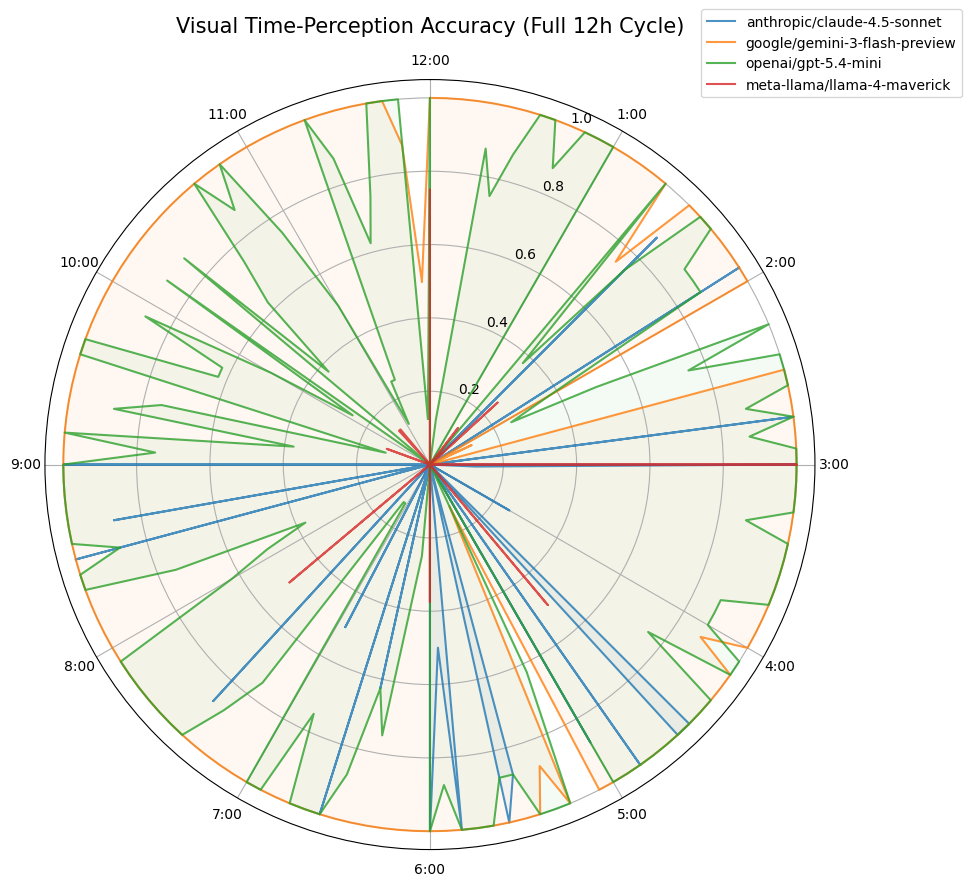

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.DataFrame(results)

# 1. Summary Table
summary = df.groupby('model').agg({
    'is_correct': ['count', 'mean'],
    'error_prob': ['mean']
}).reset_index()
summary.columns = ['Model', 'Total Tests', 'Accuracy', 'Mean Error Prob']
display(summary)

# 2. Radar Plot
# Group by model and ground_truth to get accuracy per time slice
time_accuracy = df.groupby(['model', 'ground_truth'])['is_correct'].mean().reset_index()

def time_to_angle(time_str):
    h, m = map(int, time_str.split(':'))
    total_minutes = (h % 12) * 60 + m
    fraction = total_minutes / 720.0
    # Map 00:00 to North (pi/2) and go clockwise
    return (0.5 * np.pi - (fraction * 2 * np.pi)) % (2 * np.pi)

time_accuracy['angle'] = time_accuracy['ground_truth'].apply(time_to_angle)
time_accuracy = time_accuracy.sort_values('angle', ascending=False)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, polar=True)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

models = time_accuracy['model'].unique()
for model in models:
    model_data = time_accuracy[time_accuracy['model'] == model]
    angles = model_data['angle'].tolist()
    accuracies = model_data['is_correct'].tolist()

    # Close loop
    angles += angles[:1]
    accuracies += accuracies[:1]

    ax.plot(angles, accuracies, label=model, linewidth=1.5, alpha=0.8)
    ax.fill(angles, accuracies, alpha=0.05)

ax.set_xticks(np.linspace(0, 2*np.pi, 12, endpoint=False))
ax.set_xticklabels(['12:00', '1:00', '2:00', '3:00', '4:00', '5:00', '6:00', '7:00', '8:00', '9:00', '10:00', '11:00'])
plt.title("Visual Time-Perception Accuracy (Full 12h Cycle)", size=15, y=1.05)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.show()

# Downloadable clocks (For out of band testing of other AI systems)

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image

# 1. Select 10 random samples from evaluation_data
sampled_data = random.sample(evaluation_data, min(10, len(evaluation_data)))

# 2. Set up the plotting grid
plt.figure(figsize=(20, 8))

for i, item in enumerate(sampled_data):
    img = Image.open(item['path'])
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(f"Time: {item['time']}\nFile: {os.path.basename(item['path'])}")
    plt.axis('off')

plt.tight_layout()
plt.show()